Shape       : (395, 33)
Columns     : ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5     

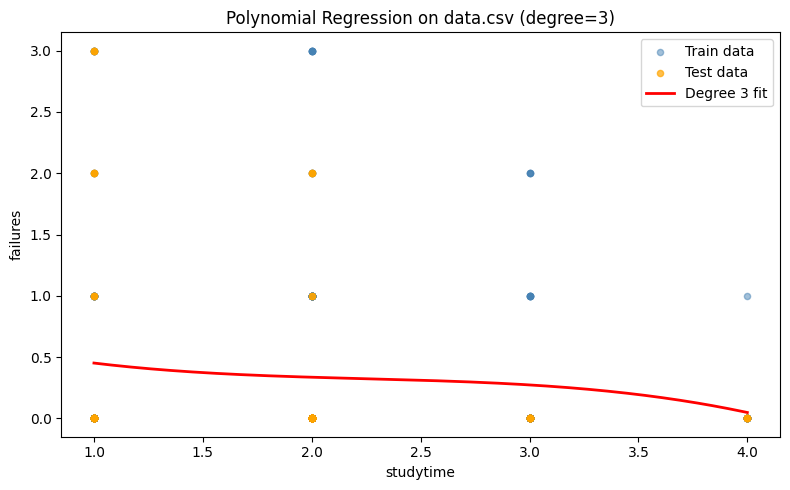

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

# ── 1. Load data ──────────────────────────────────────────────────────────────
df = pd.read_csv('student_data.csv')

print("Shape       :", df.shape)
print("Columns     :", df.columns.tolist())
print(df.head())

# ── 2. Define features and target ─────────────────────────────────────────────
# CHANGE THESE to match your actual column names

X = df[['studytime']].values   # shape (n, 1)
y = df['failures'].values      # shape (n,)

# ── 3. Handle missing values ──────────────────────────────────────────────────
df = df[['studytime', 'failures']].dropna()
print(f"\nRows after dropping NaN: {len(df)}")

# ── 4. Train / test split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── 5. Build pipeline ─────────────────────────────────────────────────────────
degree = 3   # change this: 1=line, 2=parabola, 3=curve, 5+=risk of overfit
model = Pipeline([
    ('poly',       PolynomialFeatures(degree=degree, include_bias=False)),
    ('regression', LinearRegression())
])

# ── 6. Train ──────────────────────────────────────────────────────────────────
model.fit(X_train, y_train)

# ── 7. Evaluate ───────────────────────────────────────────────────────────────
y_pred = model.predict(X_test)

print(f"\n── Results ───────────────────────────────")
print(f"Degree   : {degree}")
print(f"R² Score : {r2_score(y_test, y_pred):.4f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

# ── 8. Coefficients ───────────────────────────────────────────────────────────
poly = model.named_steps['poly']
reg  = model.named_steps['regression']
print(f"\nFeatures created : {poly.get_feature_names_out(['studytime']).tolist()}")
print(f"Coefficients     : {reg.coef_}")
print(f"Intercept        : {reg.intercept_:.4f}")

# ── 9. Compare multiple degrees ───────────────────────────────────────────────
print(f"\n── Degree Comparison ─────────────────────")
print(f"{'Degree':<10} {'R² (test)':<15} {'RMSE (test)'}")
for d in [1, 2, 3, 4, 5]:
    m = Pipeline([
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('reg',  LinearRegression())
    ])
    m.fit(X_train, y_train)
    preds = m.predict(X_test)
    print(f"{d:<10} {r2_score(y_test, preds):<15.4f} {np.sqrt(mean_squared_error(y_test, preds)):.4f}")

# ── 10. Plot ──────────────────────────────────────────────────────────────────
X_plot = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
y_plot = model.predict(X_plot)
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='steelblue', alpha=0.5, s=20, label='Train data')
plt.scatter(X_test,  y_test,  color='orange',    alpha=0.7, s=20, label='Test data')
plt.plot(X_plot, y_plot, color='red', linewidth=2, label=f'Degree {degree} fit')
plt.title(f'Polynomial Regression on data.csv (degree={degree})')
plt.xlabel('studytime')
plt.ylabel('failures')
plt.legend()
plt.tight_layout()
plt.show()

Polynomial Regression
Linear regression fits a straight line. Polynomial regression fits a curve by adding powers of the feature (x², x³, etc.) as new features.

2 degree is best for simple curve , 1 degree risks underfitting , 3+ degree risk of overfitting 

